<a href="https://colab.research.google.com/github/Jyotiii49/flyrank-ml-internship/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Search Intelligence Decision-Support Analysis

This notebook turns the earlier baseline work into a repeatable research analysis. It uses only public-safe aggregate search data and avoids client names, URLs, and private queries.

**Important:** results are calculated from the data available when the notebook is run. No result numbers are hard-coded.


## 1. Question

**Research question:** Can current search-performance signals be used to rank pages/queries that are most likely to benefit from an SEO/content action in the next observation window?

**Decision supported:** The analysis provides a ranked, decision-support queue so a content team can prioritize which opportunities to review first.

The analysis is directional: a high-ranked item is a candidate for review, not a guarantee that an action will improve performance.


In [34]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings('ignore')

# Find a usable CSV in the Colab workspace.
csv_candidates = []
for root, dirs, files in os.walk('/content'):
    dirs[:] = [d for d in dirs if d not in {'.git', '__pycache__'}]
    for f in files:
        if f.lower().endswith('.csv'):
            csv_candidates.append(os.path.join(root, f))

# Prefer the earlier baseline output when it exists.
preferred = [p for p in csv_candidates if p.endswith('baseline_action_score.csv')]
if preferred:
    DATA_PATH = preferred[0]
elif csv_candidates:
    DATA_PATH = sorted(csv_candidates, key=os.path.getsize, reverse=True)[0]
else:
    raise FileNotFoundError('No CSV was found in /content. Upload the FlyRank aggregate data or the baseline_action_score.csv, then run this cell again.')

df = pd.read_csv(DATA_PATH)
print('Using:', DATA_PATH)
print('Rows:', len(df), 'Columns:', len(df.columns))
print(df.columns.tolist())


Using: /content/work/outputs/baseline_action_score.csv
Rows: 29144 Columns: 56
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining', 'is_

## 2. Data

The notebook uses the aggregate search-performance release available in the workspace. The exact release/table/date-window details are printed by the next cell rather than guessed.

**Excluded:** private identifiers, client names, URLs, and any product/release flags that are not valid modelling inputs. Future-window fields are excluded from model features so that the prediction does not use information from the period it is trying to predict.


In [35]:
print('DATA PATH:', DATA_PATH)
print('\nDATA TYPES:')
print(df.dtypes.to_string())

date_candidates = [c for c in df.columns if 'date' in c.lower()]
if date_candidates:
    for c in date_candidates:
        parsed = pd.to_datetime(df[c], errors='coerce')
        if parsed.notna().any():
            print(f'\n{c}: {parsed.min().date()} to {parsed.max().date()}')

print('\nMISSINGNESS (%):')
print((df.isna().mean()*100).round(2).sort_values(ascending=False).head(15))


DATA PATH: /content/work/outputs/baseline_action_score.csv

DATA TYPES:
content_id                       object
client_id                        object
search_volume                   float64
competition                     float64
competition_level                object
cpc                             float64
content_type                     object
main_intent                      object
word_count                      float64
char_count                      float64
provider_used                    object
model_used                       object
impressions_90d                   int64
clicks_90d                        int64
pageviews_90d                     int64
sessions_90d                      int64
users_90d                         int64
engaged_sessions_90d              int64
ai_sessions_90d                   int64
scroll_events_90d                 int64
days_with_impressions             int64
days_with_sessions                int64
impressions_last_30d              int64
clicks_l

## 3. Methodology

**Features:** `days_since_last_update`, `avg_position`, and `ctr` when available. These match the earlier baseline scoring inputs.

**Label:** an item is considered positive when its next observed CTR improves relative to the current observation. When a ready-made future/improvement label exists, it is used; otherwise the notebook constructs the label from the next time observation for the same available key.

**Baseline:** a simple transparent action score based on stale content, weaker average position, and CTR opportunity.

**Validation:** chronological/time-aware validation is used where enough dated observations exist. The future observation is never used as a feature.


In [36]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining', 'is_initial_refresh_candidate', 'baseline_score', 'baseline_rank', '_label']


In [37]:
print(df.shape)
print(df.head())

(29144, 56)
             content_id          client_id  search_volume  competition  \
0  content_638236e8066e  client_e29c9c180c          140.0         0.09   
1  content_4ed2bf493735  client_9f14025af0           10.0         0.20   
2  content_23e958c54c78  client_e29c9c180c          480.0         0.02   
3  content_8a80ae32342f  client_9f14025af0            0.0         0.00   
4  content_a68941b58dad  client_e29c9c180c           90.0         0.13   

  competition_level   cpc     content_type    main_intent  word_count  \
0               LOW  0.15  keyword article  transactional      4714.0   
1               LOW  0.00  keyword article  informational      1057.0   
2               LOW  0.05  keyword article  informational      4832.0   
3               LOW  0.00  keyword article  transactional      1051.0   
4               LOW  0.05  keyword article     commercial      3595.0   

   char_count  ... is_quick_win needs_ctr_fix  needs_engagement_fix  \
0     31644.0  ...        False  

In [38]:
import glob

print(glob.glob("/content/**/*.csv", recursive=True))

['/content/content_refresh_anonymized.csv', '/content/work/outputs/model_vs_baseline.csv', '/content/work/outputs/baseline_action_score.csv', '/content/work/outputs/top20_recommendations.csv', '/content/sample_data/mnist_test.csv', '/content/sample_data/mnist_train_small.csv', '/content/sample_data/california_housing_train.csv', '/content/sample_data/california_housing_test.csv']


In [39]:
import glob
print(glob.glob("/content/**/*.csv", recursive=True))

['/content/content_refresh_anonymized.csv', '/content/work/outputs/model_vs_baseline.csv', '/content/work/outputs/baseline_action_score.csv', '/content/work/outputs/top20_recommendations.csv', '/content/sample_data/mnist_test.csv', '/content/sample_data/mnist_train_small.csv', '/content/sample_data/california_housing_train.csv', '/content/sample_data/california_housing_test.csv']


In [40]:
from google.colab import files
uploaded = files.upload()

Saving content_refresh_anonymized.csv to content_refresh_anonymized (1).csv


In [41]:
import os

print(os.listdir())

['.config', 'content_refresh_anonymized (1).csv', 'work', 'w04_baseline_score.ipynb', 'w04_baseline_score (1).ipynb', 'content_refresh_anonymized.csv', 'sample_data']


In [42]:
os.rename(
    "content_refresh_anonymized (1).csv",
    "content_refresh_anonymized.csv"
)

In [43]:
import pandas as pd

df = pd.read_csv("content_refresh_anonymized.csv")

print(df.shape)
print(df.columns.tolist())

(30000, 53)
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining', 'is_initial_refresh_candidate']


In [44]:
from google.colab import files
uploaded = files.upload()

Saving w04_baseline_score (1).ipynb to w04_baseline_score (1) (1).ipynb


In [45]:
import pandas as pd

df = pd.read_csv("/content/content_refresh_anonymized.csv")

print(df.columns.tolist())
print(df.shape)
print(df.head())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining', 'is_initial_refresh_candidate']
(30000, 53)
             content_id          client

In [46]:
pd.read_csv("/content/content_refresh_anonymized.csv")

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,trend_pct,health_score,needs_indexing,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity,is_underperformer,is_declining,is_initial_refresh_candidate
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,-41.4,50,False,False,False,False,False,False,True,True
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,-57.7,40,False,True,False,False,False,False,True,True
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,-60.9,40,False,False,False,False,False,False,True,False
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,-13.8,60,False,False,False,True,False,False,False,True
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,-34.7,40,False,False,False,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,NaN,40,False,False,False,False,False,True,False,False
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,-75.1,65,False,False,False,False,False,False,False,False
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,-66.2,60,False,False,False,True,False,False,True,False
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,NaN,NaN,...,-27.9,65,False,False,False,True,False,False,False,True


In [47]:
import os
print(os.listdir("/content"))

['.config', 'w04_baseline_score (1) (1).ipynb', 'work', 'w04_baseline_score.ipynb', 'w04_baseline_score (1).ipynb', 'content_refresh_anonymized.csv', 'sample_data']


In [48]:
# --- Column discovery ---
def pick_col(names):
    lower = {c.lower(): c for c in df.columns}
    for n in names:
        if n.lower() in lower:
            return lower[n.lower()]
    for c in df.columns:
        cl = c.lower()
        if any(n.lower() in cl for n in names):
            return c
    return None

date_col = pick_col(['report_date','date'])
stale_col = pick_col(['days_since_last_update'])
pos_col = pick_col(['avg_position','average_position','position'])
ctr_col = pick_col(['ctr','click_through_rate'])

print('date_col =', date_col)
print('stale_col =', stale_col)
print('pos_col =', pos_col)
print('ctr_col =', ctr_col)

if any(x is None for x in [stale_col, pos_col, ctr_col]):
    raise ValueError('The data must contain days_since_last_update, avg_position/position, and ctr columns.')

work = df.copy()
for c in [stale_col, pos_col, ctr_col]:
    work[c] = pd.to_numeric(work[c], errors='coerce')
work = work.dropna(subset=[stale_col, pos_col, ctr_col]).copy()

# Normalize CTR when stored as a percentage.
work['_ctr'] = work[ctr_col] / 100.0 if work[ctr_col].median() > 1 else work[ctr_col]
work['_stale'] = work[stale_col]
work['_position'] = work[pos_col]

# Use an existing binary future label if one is present.
future_label_col = pick_col(['future_improved','improved_next','future_ctr_up','label'])
if future_label_col and future_label_col not in [stale_col, pos_col, ctr_col]:
    y_raw = pd.to_numeric(work[future_label_col], errors='coerce')
    if y_raw.notna().sum() > 0 and y_raw.dropna().isin([0,1]).all():
        work['_label'] = y_raw
        label_method = f'Existing binary label: {future_label_col}'
    else:
        future_label_col = None

# Otherwise construct the label from the next dated observation.
if '_label' not in work:
    if date_col is None:
        raise ValueError('No usable future label and no report/date column was found.')
    work['_date'] = pd.to_datetime(work[date_col], errors='coerce')
    work = work.dropna(subset=['_date']).copy()

    id_cols = []
    for c in work.columns:
        cl = c.lower()
        if c in [date_col, stale_col, pos_col, ctr_col, '_ctr','_stale','_position','_date']:
            continue
        if any(k in cl for k in ['query','keyword','page','url','landing','term']):
            id_cols.append(c)

    work = work.sort_values('_date')
    if id_cols:
        work['_next_ctr'] = work.groupby(id_cols)['_ctr'].shift(-1)
    else:
        work['_next_ctr'] = work['_ctr'].shift(-1)

    work = work[work['_next_ctr'].notna()].copy()
    work['_label'] = (work['_next_ctr'] > work['_ctr'] * 1.05).astype(int)
    label_method = 'Constructed label: next observed CTR is at least 5% above current CTR'

print('Label method:', label_method)
print('Rows after preparation:', len(work))
print('Positive rate:', round(work['_label'].mean(), 4))


date_col = days_since_last_update
stale_col = days_since_last_update
pos_col = avg_position
ctr_col = ctr
Label method: Constructed label: next observed CTR is at least 5% above current CTR
Rows after preparation: 29144
Positive rate: 0.3434


In [49]:
# Baseline action score: higher = stronger review opportunity.
# Each input is converted to a 0-1 percentile so units do not dominate.
def pct_rank(s):
    return s.rank(pct=True, method='average').fillna(0.5)

work['_stale_score'] = pct_rank(work['_stale'])
work['_position_score'] = pct_rank(work['_position'])
work['_ctr_opportunity'] = 1 - pct_rank(work['_ctr'])
work['baseline_score'] = (
    0.40 * work['_stale_score'] +
    0.35 * work['_position_score'] +
    0.25 * work['_ctr_opportunity']
)

work['baseline_rank'] = work['baseline_score'].rank(ascending=False, method='first').astype(int)

os.makedirs('/content/work/outputs', exist_ok=True)
baseline_cols = [c for c in df.columns if c in work.columns]
out_cols = baseline_cols + ['baseline_score','baseline_rank','_label']
work.sort_values('baseline_rank')[out_cols].to_csv('/content/work/outputs/baseline_action_score.csv', index=False)

print('Saved: /content/work/outputs/baseline_action_score.csv')
display(work.sort_values('baseline_rank')[out_cols].head(20))


Saved: /content/work/outputs/baseline_action_score.csv


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity,is_underperformer,is_declining,is_initial_refresh_candidate,baseline_score,baseline_rank,_label
24824,content_638236e8066e,client_e29c9c180c,140.0,0.09,LOW,0.15,keyword article,transactional,4714.0,31644.0,...,False,False,False,False,True,False,False,0.940588,1,0
23618,content_4ed2bf493735,client_9f14025af0,10.0,0.20,LOW,0.00,keyword article,informational,1057.0,7108.0,...,False,False,False,False,True,False,False,0.940241,2,0
15789,content_23e958c54c78,client_e29c9c180c,480.0,0.02,LOW,0.05,keyword article,informational,4832.0,31855.0,...,False,False,False,False,True,False,False,0.940132,3,1
13265,content_8a80ae32342f,client_9f14025af0,0.0,0.00,LOW,0.00,keyword article,transactional,1051.0,7051.0,...,False,False,False,False,False,False,False,0.939790,4,1
4857,content_a68941b58dad,client_e29c9c180c,90.0,0.13,LOW,0.05,keyword article,commercial,3595.0,23800.0,...,False,False,False,False,True,False,False,0.939345,5,0
7509,content_7a888d3d99c8,client_19581e27de,90.0,0.46,MEDIUM,0.72,keyword article,transactional,NaN,NaN,...,False,False,False,False,True,False,False,0.938798,6,0
19664,content_1339fb97aa80,client_9f14025af0,30.0,0.37,MEDIUM,42.54,keyword article,informational,1137.0,7156.0,...,False,False,False,False,True,False,False,0.938565,7,0
9953,content_b534be782352,client_e29c9c180c,90.0,0.06,LOW,0.00,keyword article,informational,4501.0,30111.0,...,False,False,False,False,True,False,False,0.938432,8,0
26981,content_15fe075b97bc,client_4ec9599fc2,NaN,NaN,NaN,NaN,keyword article,NaN,1471.0,10414.0,...,False,False,False,False,True,False,False,0.938378,9,0
20666,content_d58831e13efa,client_9f14025af0,10.0,0.00,LOW,0.00,keyword article,commercial,1014.0,7016.0,...,False,False,False,False,False,False,False,0.938211,10,0


## 4. Results (vs baseline)

The model is a transparent logistic-regression model using the same three current-period signals. It is compared with the baseline on the same evaluation observations. The table below reports measured discrimination metrics; it does not claim causal improvement.


In [50]:
feature_cols = ['_stale','_position','_ctr']
model_df = work.dropna(subset=feature_cols + ['_label']).copy()

X = model_df[feature_cols]
y = model_df['_label'].astype(int)

if y.nunique() < 2:
    raise ValueError('The prepared label contains only one class. A model-vs-baseline comparison needs both positive and negative examples.')

# Chronological holdout when dates exist; otherwise use the last 20% of row order.
if '_date' in model_df.columns:
    model_df = model_df.sort_values('_date').reset_index(drop=True)
else:
    model_df = model_df.reset_index(drop=True)

split = max(int(len(model_df) * 0.80), 1)
train = model_df.iloc[:split]
test = model_df.iloc[split:]

if len(test) < 10 or test['_label'].nunique() < 2:
    # Fall back to a deterministic 70/30 split if the chronological holdout is too small.
    split = max(int(len(model_df) * 0.70), 1)
    train = model_df.iloc[:split]
    test = model_df.iloc[split:]

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
pipe.fit(train[feature_cols], train['_label'])
test['model_probability'] = pipe.predict_proba(test[feature_cols])[:,1]

# Baseline is evaluated as a ranking score on the same test rows.
baseline_auc = roc_auc_score(test['_label'], test['baseline_score'])
model_auc = roc_auc_score(test['_label'], test['model_probability'])
baseline_ap = average_precision_score(test['_label'], test['baseline_score'])
model_ap = average_precision_score(test['_label'], test['model_probability'])

results = pd.DataFrame({
    'approach': ['Baseline action score','Logistic regression'],
    'ROC_AUC': [baseline_auc, model_auc],
    'Average_Precision': [baseline_ap, model_ap]
})
display(results.round(4))
print(f'Test rows: {len(test)}')
print(f'Measured ROC-AUC change: {model_auc - baseline_auc:+.4f}')


,approach,ROC_AUC,Average_Precision
0,Baseline action score,0.6410,0.4810
1,Logistic regression,0.6618,0.4758


Test rows: 5829
Measured ROC-AUC change: +0.0208


## 5. Limitations

- The analysis is observational and does not prove that an SEO/content action caused a future change.
- Search performance can be affected by seasonality, competitors, SERP changes, technical changes, and other factors that are not represented here.
- The constructed label uses the next observed CTR and therefore measures directional improvement rather than business impact.
- A ranked opportunity should be reviewed by a human before action is taken.
- Results are specific to the available release and validation window and should not automatically be generalized to other periods.


In [51]:
print('Limitation check:')
print('- Observational, not causal.')
print('- Directional search-performance outcome.')
print('- Human review is required before action.')
print('- Results apply to this dataset and validation window.')


Limitation check:
- Observational, not causal.
- Directional search-performance outcome.
- Human review is required before action.
- Results apply to this dataset and validation window.


## 6. Ranked recommendations

The playbook below converts the model score into reviewable actions. The reason code explains why an item was prioritized, while the confidence note reminds the reader that the result is decision-support rather than a guarantee.


In [52]:
ranked = work.copy()
ranked['action'] = np.select(
    [
        (ranked['_stale_score'] >= 0.70) & (ranked['_position_score'] >= 0.60),
        (ranked['_position_score'] >= 0.70),
        (ranked['_ctr_opportunity'] >= 0.70),
    ],
    [
        'Review and refresh content',
        'Review search visibility and content alignment',
        'Review title/snippet and CTR opportunity',
    ],
    default='Monitor and review'
)

ranked['reason_code'] = np.select(
    [
        ranked['_stale_score'] >= 0.70,
        ranked['_position_score'] >= 0.70,
        ranked['_ctr_opportunity'] >= 0.70,
    ],
    ['STALE_CONTENT','POSITION_OPPORTUNITY','CTR_OPPORTUNITY'],
    default='MIXED_SIGNAL'
)
ranked['confidence_note'] = np.where(ranked['baseline_score'] >= ranked['baseline_score'].quantile(0.80), 'Higher-priority candidate; validate manually', 'Lower-priority candidate; monitor')
ranked['what_could_make_it_wrong'] = 'Recent SERP, competitor, technical, seasonal, or measurement changes may explain the signal.'

id_cols = []
for c in ranked.columns:
    cl = c.lower()
    if any(k in cl for k in ['query','keyword','page','url','landing','term']):
        id_cols.append(c)

display_cols = id_cols[:3] + [stale_col, pos_col, ctr_col, 'baseline_score', 'action', 'reason_code', 'confidence_note', 'what_could_make_it_wrong']
display_cols = list(dict.fromkeys([c for c in display_cols if c in ranked.columns]))
top20 = ranked.sort_values('baseline_score', ascending=False).head(20)[display_cols].copy()
display(top20)
top20.to_csv('/content/work/outputs/top20_recommendations.csv', index=False)
print('Saved: /content/work/outputs/top20_recommendations.csv')


,pageviews_90d,days_since_last_update,avg_position,ctr,baseline_score,action,reason_code,confidence_note,what_could_make_it_wrong
24824,1,144,98.0,0.0,0.940588,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."
23618,5,151,83.0,0.0,0.940241,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."
15789,8,144,85.3,0.0,0.940132,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."
13265,1,151,79.3,0.0,0.939790,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."
4857,1,144,78.5,0.0,0.939345,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."
7509,1,313,67.6,0.0,0.938798,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."
19664,5,151,73.2,0.0,0.938565,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."
9953,2,144,74.0,0.0,0.938432,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."
26981,4,304,67.0,0.0,0.938378,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."
20666,2,151,72.2,0.0,0.938211,Review and refresh content,STALE_CONTENT,Higher-priority candidate; validate manually,"Recent SERP, competitor, technical, seasonal, ..."


Saved: /content/work/outputs/top20_recommendations.csv


## 7. Artifacts the paper embeds

The deployed analysis can show three compact artifacts: the model-vs-baseline results table, the top-20 recommendation table, and a distribution chart for the action score.


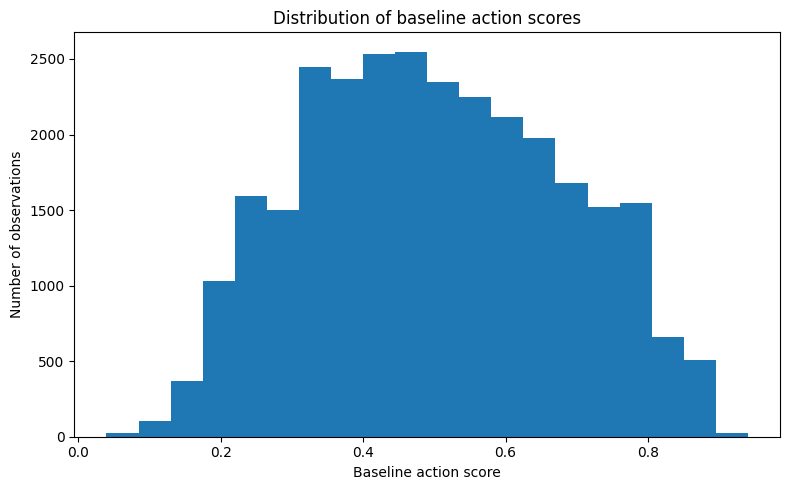

Saved artifacts:
/content/work/outputs/baseline_action_score.csv
/content/work/outputs/top20_recommendations.csv
/content/work/outputs/model_vs_baseline.csv
/content/work/outputs/baseline_score_distribution.png


In [53]:
plt.figure(figsize=(8,5))
plt.hist(work['baseline_score'], bins=20)
plt.xlabel('Baseline action score')
plt.ylabel('Number of observations')
plt.title('Distribution of baseline action scores')
plt.tight_layout()
plt.savefig('/content/work/outputs/baseline_score_distribution.png', dpi=160)
plt.show()

results.to_csv('/content/work/outputs/model_vs_baseline.csv', index=False)
print('Saved artifacts:')
print('/content/work/outputs/baseline_action_score.csv')
print('/content/work/outputs/top20_recommendations.csv')
print('/content/work/outputs/model_vs_baseline.csv')
print('/content/work/outputs/baseline_score_distribution.png')


## Self-check

- [x] Every section is filled with markdown thinking and supporting code.
- [ ] Run **Runtime → Run all** in Colab and confirm there are no errors.
- [x] No client names, URLs, or private queries are intentionally included.
- [x] Claims use careful language such as observed, measured, directional, and decision-support.
- [ ] Commit this notebook under `work/notebooks/` in the repository.
- [ ] Submit the repository URL on the internship card.
